In [1]:
#############################################
##### this is a test script for axolotl tracking 
##### modified based on the original code https://github.com/vivekhsridhar/tracktor/blob/master/examples/3g%20Zebrafish_schooling.ipynb
#############################################

In [2]:
import numpy as np
import pandas as pd
import cv2
import sys
import time
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

In [3]:
import matplotlib.pyplot as plt

## Global parameters
This cell (below) enlists user-defined parameters

In [4]:
# colours is a vector of BGR values which are used to identify individuals in the video
# since we only have one individual, the program will only use the first element from this array i.e. (0,0,255) - red
# number of elements in colours should be greater than n_inds (THIS IS NECESSARY FOR VISUALISATION ONLY)
n_inds = 1
colours = [(255,0,0),(0,255,255),(255,0,255),(255,255,255),(255,255,0),(255,0,0),(0,255,0),(0,0,0)]

# this is the block_size and offset used for adaptive thresholding (block_size should always be odd)
# these values are critical for tracking performance
block_size = 51
offset = 20

# minimum area and maximum area occupied by the animal in number of pixels
# this parameter is used to get rid of other objects in view that might be hard to threshold out but are differently sized
min_area = 200
max_area = 1000

# the scaling parameter can be used to speed up tracking if video resolution is too high (use value 0-1)
scaling = 1.0

# mot determines whether the tracker is being used in noisy conditions to track a single object or for multi-object
# using this will enable k-means clustering to force n_inds number of animals
mot = False

# name of source video and paths
video = 'axolotl'
input_vidpath = '/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/animal_tracing_test/test_video_Deniz/1_D1/Basler_acA2040-120um__24899445__20260407_140424600_%04d.tiff'
output_vidpath = '/Users/jingkui.wang/workspace/imp/image_analysis_test/results/test_video_tracktor/' + video + '.mp4'
output_filepath = '/Users/jingkui.wang/workspace/imp/image_analysis_test/results/test_video_tracktor/' + video + '.csv'
codec = 'DIVX' # try other codecs if the default doesn't work ('DIVX', 'avc1', 'XVID') note: this list is non-exhaustive

In [5]:
cap = cv2.VideoCapture(input_vidpath)
## Open video
#cap = cv2.VideoCapture(input_vidpath)
if cap.isOpened() == False:
    sys.exit('Video file cannot be read! Please check input_vidpath to ensure it is correctly pointing to the video file')

In [6]:
fourcc = cv2.VideoWriter_fourcc(*codec)
fourcc

1482049860

In [7]:
output_framesize = (int(cap.read()[1].shape[1]*scaling),int(cap.read()[1].shape[0]*scaling))
output_framesize

(300, 300)

In [7]:
## test one frame 
## Video writer class to output video with contour and centroid of tracked object(s)
# make sure the frame size matches size of array 'final'

output_framesize = (int(cap.read()[1].shape[1]*scaling),int(cap.read()[1].shape[0]*scaling))
out = cv2.VideoWriter(filename = output_vidpath, fourcc = fourcc, fps = 30.0, 
                      frameSize = output_framesize, isColor = True)

OpenCV: FFMPEG: tag 0x58564944/'DIVX' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


In [8]:
## Individual location(s) measured in the last and current step
meas_last = list(np.zeros((n_inds,2)))
meas_now = list(np.zeros((n_inds,2)))
df = []

In [10]:
meas_last

[array([0., 0.])]

In [99]:
cap.set(1,500)
ret, frame = cap.read()
this = cap.get(1)

In [100]:
ret, this

(True, 501.0)

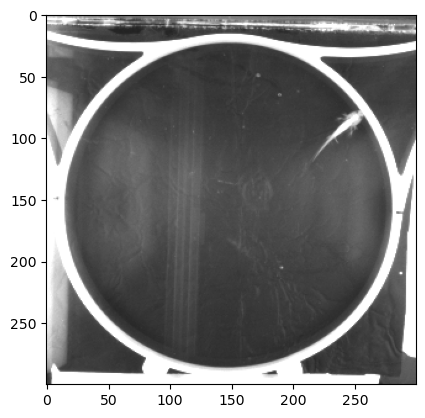

In [101]:
plt.imshow(frame,'gray')
#cv2.imshow("Image", frame)
#cv2.waitKey(0)
#cv2.destroyAllWindows()

In [102]:
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
frame = cv2.resize(frame, None, fx = scaling, fy = scaling, interpolation = cv2.INTER_LINEAR)
frame.shape

(300, 300)

In [103]:
# Apply mask to the area of interest
mask = np.zeros(frame.shape)
#mask = cv2.circle(mask, (147, 155), 130, (255,255,255), -1)
mask = cv2.circle(mask, (147, 155), 128, (255,255,255), -1)

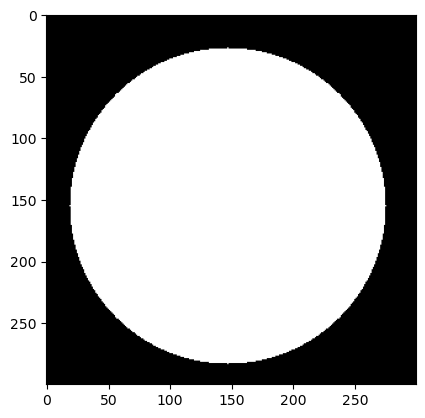

In [104]:
plt.imshow(mask,'gray')

In [105]:
np.median(frame[mask >  0])

np.float64(70.0)

In [106]:
frame[mask ==  0] = np.median(frame[mask >  0])

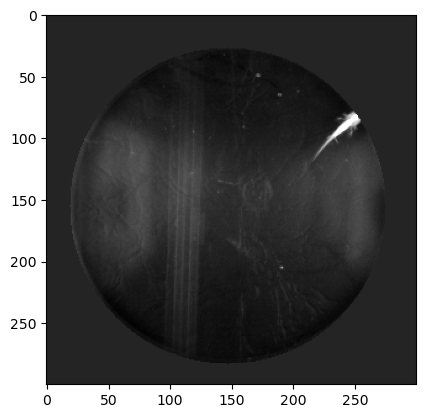

In [107]:
plt.imshow(frame,'gray')
#cv2.imshow("Image", frame)
#cv2.waitKey(0)
#cv2.destroyAllWindows()=

In [110]:
print((frame > 120).sum())

268


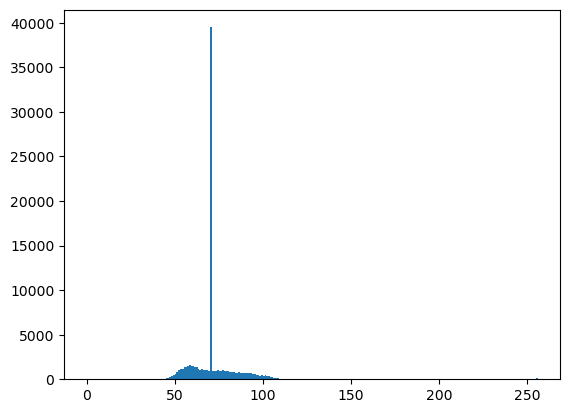

In [20]:
plt.hist(frame.ravel(), bins=256, range=(0, 256))
plt.show()

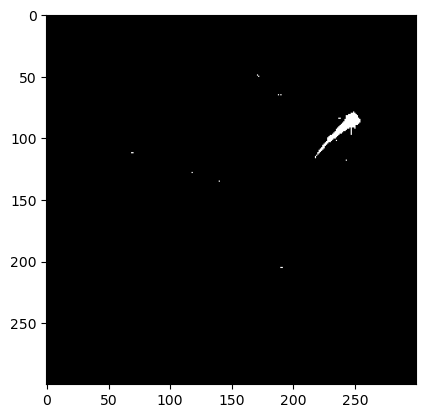

In [120]:
threshold_value = 120

_, binary = cv2.threshold(
    frame,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)
plt.imshow(binary,'gray')

In [127]:
np.sum(binary)

np.uint64(68340)

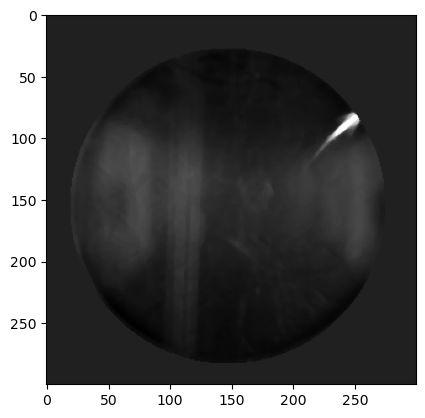

In [22]:
#blur = cv2.blur(frame, (5,5))
blur = cv2.medianBlur(frame, 5)
#blur = cv2.cvtColor(blur, cv2.COLOR_BGR2GRAY)
plt.imshow(blur,'gray')
#ret3,thresh = cv2.threshold(blur, 200, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
_, thresh_img = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#_, thresh_img = cv2.threshold(frame, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

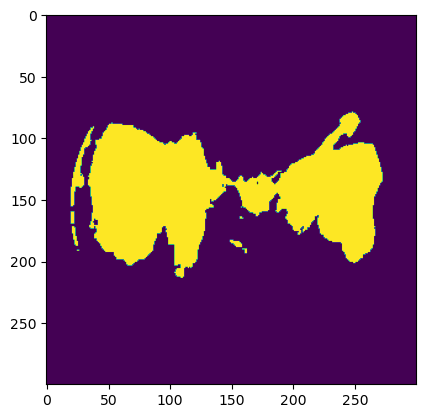

In [24]:
#plt.imshow(thresh_img)

In [13]:
np.max(frame)

np.uint8(255)

In [89]:
def gray_to_thresh(frame, block_size = 31, offset = 25):
    """
    This function retrieves a video frame and preprocesses it for object tracking.
    The code blurs image to reduce noise, converts it to greyscale and then returns a 
    thresholded version of the original image.
    
    Parameters
    ----------
    frame: ndarray, shape(n_rows, n_cols, 3)
        source image containing all three colour channels
    block_size: int(optional), default = 31
        block_size determines the width of the kernel used for adaptive thresholding.
        Note: block_size must be odd. If even integer is used, the programme will add
        1 to the block_size to make it odd.
    offset: int(optional), default = 25
        constant subtracted from the mean value within the block
        
    Returns
    -------
    thresh: ndarray, shape(n_rows, n_cols, 1)
        binarised(0,255) image
    """
    gray = cv2.blur(frame, (5,5))
    #gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    #thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, block_size, offset)
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, block_size, offset)
    
    return thresh

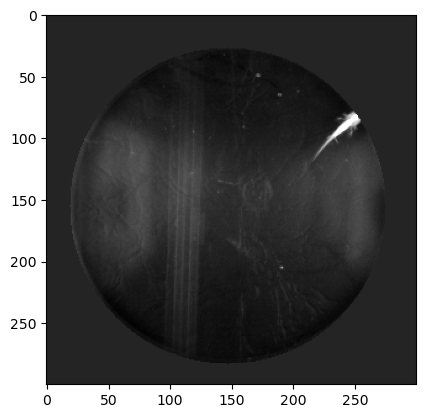

In [90]:
plt.imshow(frame,'gray')

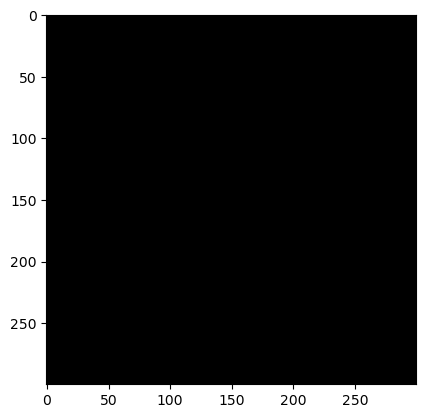

In [128]:
#import tracktor as tr
block_size = 101
offset = 40

min_area = 100
max_area = 600

thresh = gray_to_thresh(frame, block_size, offset)
plt.imshow(thresh,'gray')

In [121]:
thresh = binary
final, contours, meas_last, meas_now = tr.detect_and_draw_contours(frame, thresh, meas_last, meas_now, min_area, max_area)

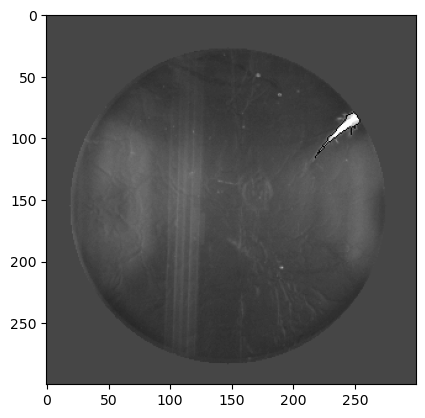

In [122]:
plt.imshow(final,'gray')

In [125]:
row_ind, col_ind = tr.hungarian_algorithm(meas_last, meas_now)
final, meas_now, df = tr.reorder_and_draw(final, colours, n_inds, col_ind, meas_now, df, mot, this)

In [129]:
colours

[(255, 0, 0),
 (0, 255, 255),
 (255, 0, 255),
 (255, 255, 255),
 (255, 255, 0),
 (255, 0, 0),
 (0, 255, 0),
 (0, 0, 0)]

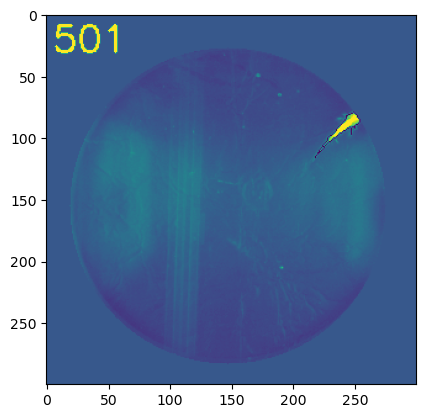

In [126]:
plt.imshow(final)

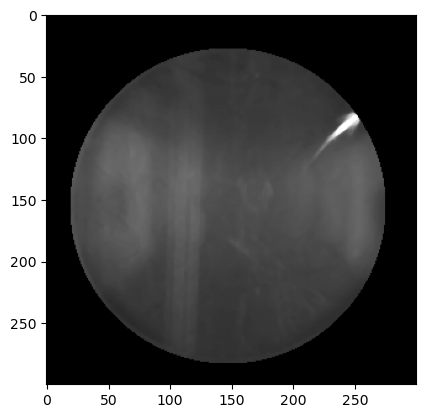

In [35]:
#blur = cv2.blur(frame, (5,5))
blur = cv2.medianBlur(frame, 5)
blur = cv2.cvtColor(blur, cv2.COLOR_BGR2GRAY)
plt.imshow(blur,'gray')
#ret3,thresh = cv2.threshold(blur, 200, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
_, thresh_img = cv2.threshold(blur, 200, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

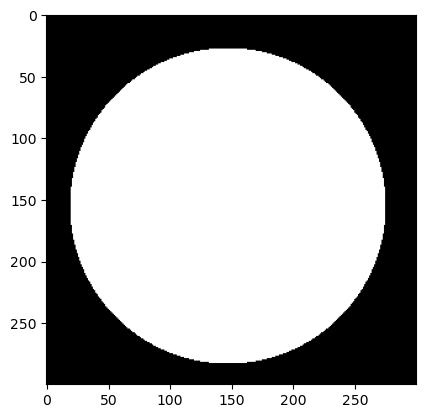

In [36]:
plt.imshow(thresh_img,'gray')

In [359]:
frame.shape, blur.shape

((300, 300, 3), (300, 300))

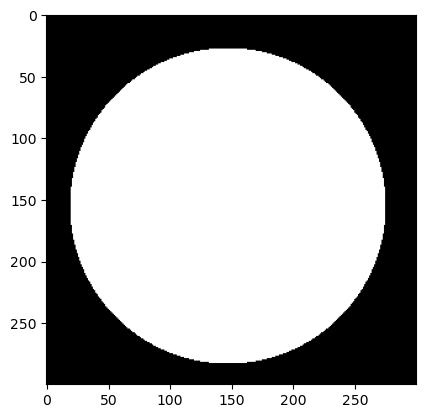

In [360]:
plt.imshow(thresh,'gray')

[[20.648738379814077, 140.14342629482073],
 [232.69005847953215, 87.10331384015595],
 [266.7739754964089, 119.44824672581325]]

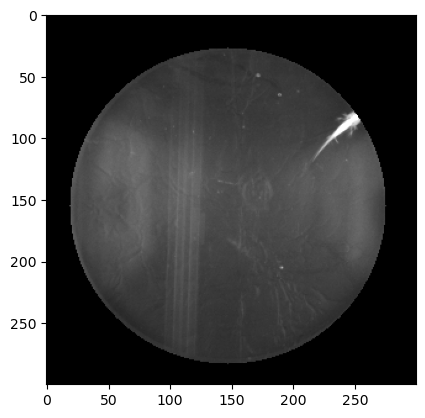

In [361]:
final, contours, meas_last, meas_now = tr.detect_and_draw_contours(frame, thresh, meas_last, meas_now, min_area, max_area)
plt.imshow(final)
meas_last

In [363]:
row_ind, col_ind = tr.hungarian_algorithm(meas_last, meas_now)
final, meas_now, df = tr.reorder_and_draw(final, colours, n_inds, col_ind, meas_now, df, mot, this)

ValueError: XA must be a 2-dimensional array.

In [120]:
row_ind, col_ind = tr.hungarian_algorithm(meas_last, meas_now)
final, meas_now, df = tr.reorder_and_draw(final, colours, n_inds, col_ind, meas_now, df, mot, this)

ValueError: XA must be a 2-dimensional array.

In [4]:
## Start time
start = time.time()

## Individual location(s) measured in the last and current step
meas_last = list(np.zeros((n_inds,2)))
meas_now = list(np.zeros((n_inds,2)))

last = 0
df = []

while(True):
    # Capture frame-by-frame
    ret, frame = cap.read()

    this = cap.get(1)
    if ret == True:
        frame = cv2.resize(frame, None, fx = scaling, fy = scaling, interpolation = cv2.INTER_LINEAR)
        
        # Apply mask to aarea of interest
        mask = np.zeros(frame.shape)
        mask = cv2.circle(mask, (308, 235), 215, (255,255,255), -1)
        frame[mask ==  0] = 0
        
        thresh = tr.colour_to_thresh(frame, block_size, offset)
        final, contours, meas_last, meas_now = tr.detect_and_draw_contours(frame, thresh, meas_last, meas_now, min_area, max_area)
        row_ind, col_ind = tr.hungarian_algorithm(meas_last, meas_now)
        final, meas_now, df = tr.reorder_and_draw(final, colours, n_inds, col_ind, meas_now, df, mot, this)
        
        # Create output dataframe
        for i in range(n_inds):
            df.append([this, meas_now[i][0], meas_now[i][1]])
        
        # Display the resulting frame
        out.write(final)
        cv2.imshow('frame', final)
        if cv2.waitKey(1) == 27:
            break
            
    if last == this:
        break
    
    last = this

## Write positions to file
df = pd.DataFrame(np.matrix(df), columns = ['frame','pos_x','pos_y'])
df.to_csv(output_filepath, sep=',')

## When everything done, release the capture
cap.release()
out.release()
cv2.destroyAllWindows()
cv2.waitKey(1)

## End time and duration
end = time.time()
duration = end - start
print("--- %s seconds ---" %duration)

OpenCV: FFMPEG: tag 0x58564944/'DIVX' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


ValueError: XA must be a 2-dimensional array.

## Plot tracks
The code below allows you to see individual tracks. By counting the number of jumps in the tracks, one can identify number of false detections.

In [10]:
df = pd.read_csv(output_filepath)
df.head()

,Unnamed: 0,frame,pos_x,pos_y
0,0,3.0,255.600187,221.473525
1,1,4.0,257.665474,221.646385
2,2,5.0,257.657863,221.611706
3,3,6.0,258.557087,223.268780
4,4,7.0,258.017197,225.061720


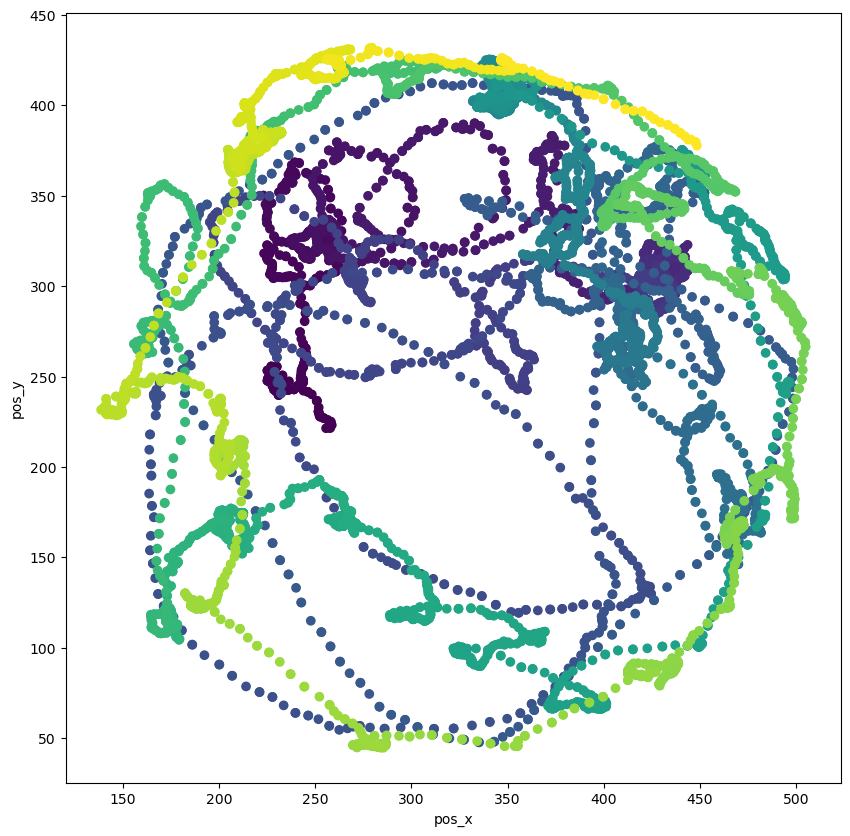

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.scatter(df['pos_x'], df['pos_y'], c=df['frame'])
plt.xlabel('pos_x')
plt.ylabel('pos_y')
plt.show()

## Identifying true/false detections
Here, we use individual movement speeds to identify false detections. All frames where individuals move faster than their body length are considered false detections.

NOTE: The methode used here underestimates false detections.

In [6]:
dx = df['pos_x'] - df['pos_x'].shift(n_inds)
dy = df['pos_y'] - df['pos_y'].shift(n_inds)
df['speed'] = np.sqrt(dx**2 + dy**2)
df.head()

,Unnamed: 0,frame,pos_x,pos_y,speed
0,0,1.0,253.032890,220.846746,NaN
1,1,2.0,255.531696,221.534269,2.591663
2,2,3.0,255.531696,221.534269,0.000000
3,3,4.0,257.646961,221.697056,2.121520
4,4,5.0,257.646961,221.697056,0.000000


In [7]:
thresh = 42.6

True detection rate

In [8]:
print(1-len(np.where(df['speed'] > thresh)[0]) / max(df['frame']))

1.0
